# Exploring Checkout Patterns for Canonical American Authors (1945 to the present)

In [47]:
import pandas as pd

In [48]:
spl_df = pd.read_csv("https://seattle-library-checkout-data.s3.us-west-2.amazonaws.com/norton-anthology_spl-checkouts_2005-2025.csv")

/var/folders/06/y6vmvyfj0wg08vb3rszcfy080000gn/T/ipykernel_52341/3367337367.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  spl_df = pd.read_csv("https://seattle-library-checkout-data.s3.us-west-2.amazonaws.com/norton-anthology_spl-checkouts_2005-2025.csv")


In [39]:
spl_df.to_csv("norton-anthology_spl-checkouts_2005-2025.csv", index = False)

In [50]:
spl_df.sample(10)

,CheckoutDate,UsageClass,CheckoutOutType,MaterialType,CheckoutYear,CheckoutMonth,Checkouts,Title,Creator,Subjects,Publisher,PublicationYear,ISBN,Normalized.Creator,Normalized.Title,BirthYear,DeathYear,Work.In.Norton
121070,2013-09-01,Physical,Horizon,BOOK,2013,9,3,A gift of gracias : the legend of Altagracia /...,"Alvarez, Julia.","Oranges Juvenile fiction, Saints Fiction, Domi...","Knopf : Distributed by Random House,",2005.0,NaN,Julia Alvarez,A Gift Of Gracias,1950,NaN,False
67941,2014-10-01,Physical,Horizon,BOOK,2014,10,1,What there is to say we have said : the corres...,"Welty, Eudora, 1909-2001","Welty Eudora 1909 2001 Correspondence, Maxwell...","Houghton Mifflin Harcourt,",2011.0,NaN,Eudora Welty,What There Is To Say We Have Said,1909,2001.0,False
60805,2020-01-01,Physical,Horizon,BOOK,2020,1,1,Falling man / Don DeLillo.,"DeLillo, Don","September 11 Terrorist Attacks 2001 Fiction, V...","Center Point Pub.,",2007.0,"1602850453, 9781602850453",Don DeLillo,Falling Man,1936,NaN,False
20130,2010-11-01,Physical,Horizon,BOOK,2010,11,2,The essential Dykes to watch out for / Alison ...,"Bechdel, Alison, 1960-","Lesbians Comic books strips etc, Comic books s...","Houghton Mifflin Harcourt,",2008,"0618968806, 9780618968800",Alison Bechdel,The Essential Dykes To Watch Out For,1960,NaN,False
46562,2019-07-01,Physical,Horizon,BOOK,2019,7,2,Fences / a play by August Wilson ; introductio...,"Wilson, August","African Americans Drama, African American fami...","Plume,",NaN,"0735216681, 9780735216686",August Wilson,Fences,1945,2005.0,True
71624,2013-04-01,Physical,Horizon,BOOK,2013,4,1,Poems retrieved / Frank O'Hara ; edited by Don...,"O'Hara, Frank, 1926-1966.",NaN,"Grey Fox Press ; distributed by Book People,",NaN,NaN,Frank O'Hara,Poems Retrieved,1926,1966.0,False
124688,2019-12-01,Digital,OverDrive,EBOOK,2019,12,1,We Are What We Pretend to Be: The First and La...,Kurt Vonnegut,"Fiction, Literature","Hachette Digital, Inc.",2012.0,9781593157449,Kurt Vonnegut,We Are What We Pretend To Be,1922,2007.0,False
56604,2009-11-01,Physical,Horizon,BOOK,2009,11,1,Selected poems / Denise Levertov ; with a pref...,"Levertov, Denise, 1923-1997",NaN,Published for James Laughlin by New Directions...,2002.0,811215202,Denise Levertov,Selected Poems,1923,1997.0,False
196103,2024-04-01,Physical,Horizon,BOOK,2024,4,1,The business of fancydancing : stories and poe...,"Alexie, Sherman, 1966-","Spokane Indians Literary collections, Short st...","Hanging Loose Press,",NaN,"0914610007, 0914610244, 9780914610007, 9780914...",Sherman Alexie,The Business Of Fancydancing,1966,NaN,False
186771,2018-02-01,Digital,OverDrive,EBOOK,2018,2,2,La Casa en Mango Street,Sandra Cisneros,"Fiction, Literature","Random House, Inc.",2015.0,9780345807205,Sandra Cisneros,The House On Mango Street,1954,NaN,False


In [4]:
spl_df["CheckoutDate"] = pd.to_datetime(
    dict(year=spl_df["CheckoutYear"], month=spl_df["CheckoutMonth"], day=1)
)

In [31]:
spl_df['Normalized.Creator'] = spl_df['Normalized.Creator'].str.replace("Delillo", "DeLillo")

In [35]:
spl_df['ISBN'] = (
    spl_df.groupby(['Creator', 'Title', 'MaterialType'])['ISBN']
      .transform(lambda s: s.ffill().bfill())
)

/var/folders/06/y6vmvyfj0wg08vb3rszcfy080000gn/T/ipykernel_52341/2174189581.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda s: s.ffill().bfill())


In [38]:
spl_df.sample(10)

,CheckoutDate,UsageClass,CheckoutOutType,MaterialType,CheckoutYear,CheckoutMonth,Checkouts,Title,Creator,Subjects,Publisher,PublicationYear,ISBN,Normalized.Creator,Normalized.Title,BirthYear,DeathYear,Work.In.Norton
167236,2018-09-01,Digital,OverDrive,EBOOK,2018,9,3,A Scanner Darkly,Philip K. Dick,"Fiction, Science Fiction","Random House, Inc.",2011.0,9780547601311,Philip K. Dick,A Scanner Darkly,1928,1982.0,False
1885,2011-11-01,Physical,Horizon,BOOK,2011,11,5,Cat dreams / by Ursula K. Le Guin ; illustrate...,"Le Guin, Ursula K., 1929-","Stories in rhyme Juvenile fiction, Cats Juveni...","Orchard Books,",2009,NaN,Ursula K. Le Guin,Cat Dreams,1929,2018.0,False
173820,2015-09-01,Physical,Horizon,BOOK,2015,9,2,The three stigmata of Palmer Eldritch / Philip...,"Dick, Philip K.","Immortalism Fiction, Space colonies Fiction, M...","Mariner Books,",2011.0,"0547572557, 9780547572550",Philip K. Dick,The Three Stigmata Of Palmer Eldritch,1928,1982.0,False
13640,2009-12-01,Physical,Horizon,BOOK,2009,12,3,All of us : the collected poems / Raymond Carver.,"Carver, Raymond, 1938-1988",NaN,"Knopf,",1998,0375403981,Raymond Carver,All Of Us,1938,1988.0,False
74782,2021-01-01,Digital,OverDrive,EBOOK,2021,1,6,"Congratulations, by the way: Some Thoughts on ...",George Saunders,"Education, Nonfiction, Philosophy, Self-Improv...","Random House, Inc.",2014.0,9780812996289,George Saunders,Congratulations By The Way,1958,NaN,False
84259,2023-11-01,Digital,OverDrive,EBOOK,2023,11,1,Subterraneans,Jack Kerouac,"Classic Literature, Fiction, Literature",Lightning Source Inc,2014.0,9780802195715,Jack Kerouac,Subterraneans,1922,1969.0,False
158544,2018-12-01,Digital,OverDrive,EBOOK,2018,12,22,"Parable of the Sower: Parable Series, Book 1",Octavia E. Butler,"Fantasy, Fiction, Science Fiction",Open Road Integrated Media,2012.0,NaN,Octavia E. Butler,Parable Of The Sower,1947,2006.0,False
58150,2019-07-01,Digital,OverDrive,EBOOK,2019,7,3,The Names,Don DeLillo,"Fiction, Literature, Suspense, Thriller","Random House, Inc.",2013.0,9780307817181,Don DeLillo,The Names,1936,NaN,False
53646,2024-01-01,Digital,OverDrive,EBOOK,2024,1,3,Brief Interviews with Hideous Men: Stories,David Foster Wallace,"Fiction, Literature, Short Stories, Humor (Fic...","Hachette Digital, Inc.",2011.0,9780316086899,David Foster Wallace,Brief Interviews With Hideous Men,1962,2008.0,False
145047,2017-07-01,Physical,Horizon,BOOK,2017,7,1,A testament of hope : the essential writings o...,"King, Martin Luther, Jr., 1929-1968","African Americans Civil rights, United States ...","Harper & Row,",NaN,NaN,Martin Luther King Jr.,A Testament Of Hope,1929,1968.0,False


In [37]:
spl_df[spl_df['Normalized.Creator'].str.contains("DeLillo")].sort_values(by="Title")

,CheckoutDate,UsageClass,CheckoutOutType,MaterialType,CheckoutYear,CheckoutMonth,Checkouts,Title,Creator,Subjects,Publisher,PublicationYear,ISBN,Normalized.Creator,Normalized.Title,BirthYear,DeathYear,Work.In.Norton
58077,2019-03-01,Digital,OverDrive,EBOOK,2019,3,2,Americana,Don DeLillo,"Classic Literature, Fiction, Literature","Penguin Group (USA), Inc.",2013.0,9781101659854,Don DeLillo,Americana,1936,NaN,False
57351,2014-02-01,Digital,OverDrive,EBOOK,2014,2,1,Americana,Don DeLillo,"Classic Literature, Fiction, Literature","Penguin Group (USA), Inc.",2013.0,9781101659854,Don DeLillo,Americana,1936,NaN,False
57359,2014-03-01,Digital,OverDrive,EBOOK,2014,3,2,Americana,Don DeLillo,"Classic Literature, Fiction, Literature","Penguin Group (USA), Inc.",2013.0,9781101659854,Don DeLillo,Americana,1936,NaN,False
58239,2020-02-01,Digital,OverDrive,EBOOK,2020,2,1,Americana,Don DeLillo,"Classic Literature, Fiction, Literature","Penguin Group (USA), Inc.",2013.0,9781101659854,Don DeLillo,Americana,1936,NaN,False
58567,2021-09-01,Digital,OverDrive,EBOOK,2021,9,1,Americana,Don DeLillo,"Classic Literature, Fiction, Literature","Penguin Group (USA), Inc.",2013.0,9781101659854,Don DeLillo,Americana,1936,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57731,2017-04-01,Digital,OverDrive,EBOOK,2017,4,11,Zero K: A Novel,Don DeLillo,"Fantasy, Fiction","Simon & Schuster, Inc.",2016.0,9781501135408,Don DeLillo,Zero K,1936,NaN,False
58505,2021-05-01,Digital,OverDrive,EBOOK,2021,5,2,Zero K: A Novel,Don DeLillo,"Fantasy, Fiction","Simon & Schuster, Inc.",2016.0,9781501135408,Don DeLillo,Zero K,1936,NaN,False
58133,2019-06-01,Digital,OverDrive,EBOOK,2019,6,1,Zero K: A Novel,Don DeLillo,"Fantasy, Fiction","Simon & Schuster, Inc.",2016.0,9781501135408,Don DeLillo,Zero K,1936,NaN,False
58516,2021-06-01,Digital,OverDrive,EBOOK,2021,6,1,Zero K: A Novel,Don DeLillo,"Fantasy, Fiction","Simon & Schuster, Inc.",2016.0,9781501135408,Don DeLillo,Zero K,1936,NaN,False


In [7]:
spl_df.head()

,CheckoutDate,UsageClass,CheckoutOutType,MaterialType,CheckoutYear,CheckoutMonth,Checkouts,Title,Creator,Subjects,Publisher,PublicationYear,ISBN,Normalized.Creator,Normalized.Title,BirthYear,DeathYear,Work.In.Norton
0,2016-10-01,Digital,OverDrive,AUDIOBOOK,2016,10,1,The Natural (Unabridged),Bernard Malamud,"Classic Literature, Fiction","Blackstone Audio, Inc.",2008,NaN,Bernard Malamud,The Natural,1914,1986.0,False
1,2016-10-01,Digital,OverDrive,EBOOK,2016,10,1,The Assistant,Bernard Malamud,"Fiction, Literature",Macmillan Publishers,2013,NaN,Bernard Malamud,The Assistant,1914,1986.0,False
2,2016-11-01,Digital,OverDrive,EBOOK,2016,11,1,The Magic Barrel,Bernard Malamud,"Fiction, Literature",Macmillan Publishers,2013,NaN,Bernard Malamud,The Magic Barrel,1914,1986.0,True
3,2016-11-01,Digital,OverDrive,EBOOK,2016,11,1,The Assistant,Bernard Malamud,"Fiction, Literature",Macmillan Publishers,2013,NaN,Bernard Malamud,The Assistant,1914,1986.0,False
4,2016-12-01,Digital,OverDrive,EBOOK,2016,12,1,The Fixer: A Novel,Bernard Malamud,"Fiction, Literature",Macmillan Publishers,2013,NaN,Bernard Malamud,The Fixer,1914,1986.0,False


## Sum Checkouts Per Month — Author and Title

In [40]:
author_checkouts_per_month = spl_df.groupby(['Normalized.Creator', 'CheckoutDate', 'Work.In.Norton'])['Checkouts'].sum().reset_index()

In [41]:
title_checkouts_per_month = spl_df.groupby(['Normalized.Title', 'Normalized.Creator',  'Work.In.Norton','CheckoutDate'])['Checkouts'].sum().reset_index()

In [42]:
title_checkouts_per_month

,Normalized.Title,Normalized.Creator,Work.In.Norton,CheckoutDate,Checkouts
0,"""All Labor Has Dignity""",Martin Luther King Jr.,False,2011-02-01,2
1,"""All Labor Has Dignity""",Martin Luther King Jr.,False,2011-09-01,1
2,"""All Labor Has Dignity""",Martin Luther King Jr.,False,2012-01-01,1
3,"""All Labor Has Dignity""",Martin Luther King Jr.,False,2012-02-01,1
4,"""All Labor Has Dignity""",Martin Luther King Jr.,False,2012-03-01,1
...,...,...,...,...,...
138926,Zuckerman Unbound,Philip Roth,False,2025-02-01,1
138927,Zuckerman Unbound,Philip Roth,False,2025-03-01,1
138928,Zuckerman Unbound,Philip Roth,False,2025-04-01,1
138929,Zuckerman Unbound,Philip Roth,False,2025-05-01,2


In [43]:
title_checkouts_per_month.to_csv("title-checkouts-per-month.csv", index = False)

In [44]:
aggregated_checkouts_title_authors = title_checkouts_per_month.groupby(['Normalized.Title', 'Normalized.Creator', 'Work.In.Norton'])['Checkouts'].sum().sort_values( ascending=False).reset_index()

In [45]:
aggregated_checkouts_title_authors

,Normalized.Title,Normalized.Creator,Work.In.Norton,Checkouts
0,Parable Of The Sower,Octavia E. Butler,False,21652
1,Lincoln In The Bardo,George Saunders,False,17356
2,The Fifth Season,N. K. Jemisin,False,17223
3,The Sympathizer,Viet Thanh Nguyen,False,12792
4,Kindred,Octavia E. Butler,False,12591
...,...,...,...,...
1643,Wise Whys Ys,Amiri Baraka,False,1
1644,Footprints,Denise Levertov,False,1
1645,Walking To Sleep,Richard Wilbur,False,1
1646,Aloneness,Gwendolyn Brooks,False,1


In [46]:
aggregated_checkouts_title_authors.to_csv("aggregated-checkouts-title-authors.csv", index=False)

## Visualize Checkouts Per Month

### Filter by Specific Title

In [18]:
title_checkouts_per_month[title_checkouts_per_month['Normalized.Title'] == "Infinite Jest"]

,Normalized.Title,Normalized.Creator,Work.In.Norton,CheckoutDate,Checkouts
48413,Infinite Jest,David Foster Wallace,False,2008-10-01,35
48414,Infinite Jest,David Foster Wallace,False,2008-11-01,44
48415,Infinite Jest,David Foster Wallace,False,2008-12-01,32
48416,Infinite Jest,David Foster Wallace,False,2009-01-01,49
48417,Infinite Jest,David Foster Wallace,False,2009-02-01,32
...,...,...,...,...,...
48607,Infinite Jest,David Foster Wallace,False,2025-02-01,42
48608,Infinite Jest,David Foster Wallace,False,2025-03-01,37
48609,Infinite Jest,David Foster Wallace,False,2025-04-01,45
48610,Infinite Jest,David Foster Wallace,False,2025-05-01,43


### Plot Specific Title

<Axes: title={'center': 'Checkouts of Infinite Jest'}, xlabel='CheckoutDate'>

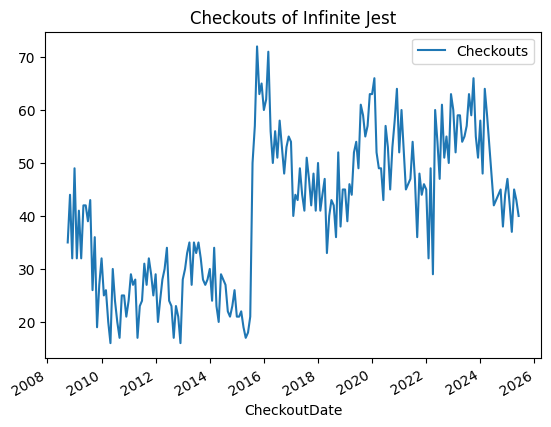

In [23]:
title_checkouts_per_month[title_checkouts_per_month['Normalized.Title'] == "Infinite Jest"].plot(x = 'CheckoutDate', y = 'Checkouts', title = 'Checkouts of Infinite Jest')